### 一、导入关键库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示（如果图表需要）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取 CSV（注意编码，尝试 utf-8 或 latin1）
df = pd.read_csv('data/Most_Streamed_Spotify_Songs_2024.csv', encoding='latin1', low_memory=False)
# 如果报编码错误，尝试 encoding='latin1' 或 'cp1252'

# 查看基本信息
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   str    
 1   Album Name                  4600 non-null   str    
 2   Artist                      4595 non-null   str    
 3   Release Date                4600 non-null   str    
 4   ISRC                        4600 non-null   str    
 5   All Time Rank               4600 non-null   str    
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   str    
 8   Spotify Playlist Count      4530 non-null   str    
 9   Spotify Playlist Reach      4528 non-null   str    
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   str    
 12  YouTube Likes               4285 non-null   str    
 13  TikTok Posts                3427 non-null   

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


### 二、数据质量检查与清洗

#### 1.处理缺失值 

In [2]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
print(pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent}))

                            Missing Values  Percentage
Track                                    0    0.000000
Album Name                               0    0.000000
Artist                                   5    0.108696
Release Date                             0    0.000000
ISRC                                     0    0.000000
All Time Rank                            0    0.000000
Track Score                              0    0.000000
Spotify Streams                        113    2.456522
Spotify Playlist Count                  70    1.521739
Spotify Playlist Reach                  72    1.565217
Spotify Popularity                     804   17.478261
YouTube Views                          308    6.695652
YouTube Likes                          315    6.847826
TikTok Posts                          1173   25.500000
TikTok Likes                           980   21.304348
TikTok Views                           981   21.326087
YouTube Playlist Reach                1009   21.934783
Apple Musi

In [3]:
# 处理缺失值（例如，填充或删除）
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

str_cols = df.select_dtypes(include=[object]).columns
df[str_cols] = df[str_cols].fillna('')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_53196\1121489692.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include=[object]).columns


#### 2. 异常值检测（以 Spotify 播放量为例）

In [4]:
df['Spotify Streams'] = df['Spotify Streams'].str.replace(',', '').replace('', '0')
df['Spotify Streams'] = pd.to_numeric(df['Spotify Streams'], errors='coerce').fillna(0)

# 描述统计
print(df['Spotify Streams'].describe())

# 找出极端值
mean = df['Spotify Streams'].mean()
std = df['Spotify Streams'].std()
outliers = df[df['Spotify Streams'] > mean + 3 * std]
print(f"发现 {len(outliers)} 个极端值")

count    4.600000e+03
mean     4.363971e+08
std      5.362792e+08
min      0.000000e+00
25%      6.340627e+07
50%      2.263761e+08
75%      6.113563e+08
max      4.281469e+09
Name: Spotify Streams, dtype: float64
发现 89 个极端值


#### 3.字段规范化（歌手名去重/trim）

In [5]:
# 去除歌手名前后空格
df['Artist'] = df['Artist'].str.strip()

# 统一大小写
df['Artist'] = df['Artist'].str.title()

# df['Artist'].value_counts().head(10)

#### 4.一致性校验

In [6]:
# 解析日期
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

# 删除无法解析的行
df = df.dropna(subset=['Release Date'])

### 三、复杂查询

#### 1.多维度聚合（group by / having）

- 按年份统计平均播放量

In [9]:
df['Year'] = df['Release Date'].dt.year
yearly_avg = df.groupby('Year')['Spotify Streams'].agg(['count','mean']).reset_index()
print(yearly_avg)

    Year  count          mean
0   1987      1  1.879386e+09
1   1991      1  2.021910e+09
2   1994      1  1.810650e+09
3   1998      1  1.783399e+08
4   1999      1  1.405354e+09
5   2000      2  1.921767e+09
6   2001      1  3.991452e+08
7   2002      5  1.812768e+09
8   2003      3  1.502681e+09
9   2004      5  1.232601e+09
10  2005      5  1.222379e+09
11  2006      3  1.096108e+09
12  2007      5  1.043205e+09
13  2008     11  1.170105e+09
14  2009     15  1.079095e+09
15  2010     27  9.675554e+08
16  2011     51  1.063550e+09
17  2012     47  1.250934e+09
18  2013     55  1.026534e+09
19  2014     70  8.442817e+08
20  2015     96  1.060685e+09
21  2016    123  9.916770e+08
22  2017    213  8.924288e+08
23  2018    249  7.669361e+08
24  2019    296  6.671265e+08
25  2020    360  5.042965e+08
26  2021    408  4.647275e+08
27  2022    694  3.020708e+08
28  2023   1158  1.945128e+08
29  2024    693  1.001403e+08


- 找出播放量高于整体均值的艺术家

In [ ]:
global_avg = df['Spotify Streams'].mean()
artist_avg = df.groupby('Artist')['Spotify Streams'].mean().reset_index()

top_artists = artist_avg[artist_avg['Spotify Streams'] > global_avg].sort_values('Spotify Streams', ascending=False).head(10)
print(top_artists)

              Artist  Spotify Streams
1913         Xsyborg     4.074842e+09
1855       Vance Joy     2.541834e+09
1492           Queen     2.486909e+09
905      John Legend     2.381097e+09
1355      Nick White     2.300430e+09
1432       Passenger     2.252714e+09
1755     The Killers     2.174022e+09
1115      Lord Huron     2.097181e+09
659   French Montana     2.065697e+09
121   Arctic Monkeys     1.982152e+09


#### 2.窗口函数（rank/row_number）找出Top歌曲/歌手

- 每个艺术家的热门歌曲排名


In [ ]:
df['rank in artist'] = df.groupby('Artist')['Spotify Streams'].rank(ascending=False, method='first')

# 查看每个艺术家的第一名歌曲
first_songs = df[df['rank in artist'] == 1]
print(first_songs[['Artist', 'Track', 'Spotify Streams']])

             Artist                                              Track  \
0     Tommy Richman                                MILLION DOLLAR BABY   
2           Artemas                         i like the way you kiss me   
3       Miley Cyrus                                            Flowers   
6      Benson Boone                                   Beautiful Things   
7        Floyymenor                                          Gata Only   
...             ...                                                ...   
4586       Serranow                                       Bodak Yellow   
4588          Steps                                             Braten   
4589     Kerim Araz                                     Dayanamï¿½ï¿½y   
4592  Jaques Raupï¿                                      3 Haselnï¿½ï¿   
4594    Bushido Zho  ýýýýýýýýýýýý (ýýýýýýýýýýýýýý ýýýýýýýýýýýý) [pr...   

      Spotify Streams  
0           390470936  
2           601309283  
3          2031280633  
6           900

- 全局播放量前 10 歌曲

In [ ]:
df['global_songs_rank'] = df['Spotify Streams'].rank(ascending=False)
top10_global_songs = df.sort_values('global_songs_rank').head(10)
print(top10_global_songs[['Artist', 'Track', 'Album Name', 'Spotify Streams']])

             Artist                                          Track  \
55       The Weeknd                                Blinding Lights   
4254        Xsyborg                                Blinding Lights   
53       Ed Sheeran                                   Shape of You   
1637        Xsyborg                                   Shape of You   
132   Lewis Capaldi                              Someone You Loved   
114     Post Malone  Sunflower - Spider-Man: Into the Spider-Verse   
19     Harry Styles                                      As It Was   
3406   Harry Styles                                      As It Was   
262      The Weeknd                                        Starboy   
519           Drake                                      One Dance   

                                         Album Name  Spotify Streams  
55                                  Blinding Lights       4281468720  
4254                                Blinding Lights       4261328190  
53              

### 四、可视化

#### 1. 缺失值比例柱状图

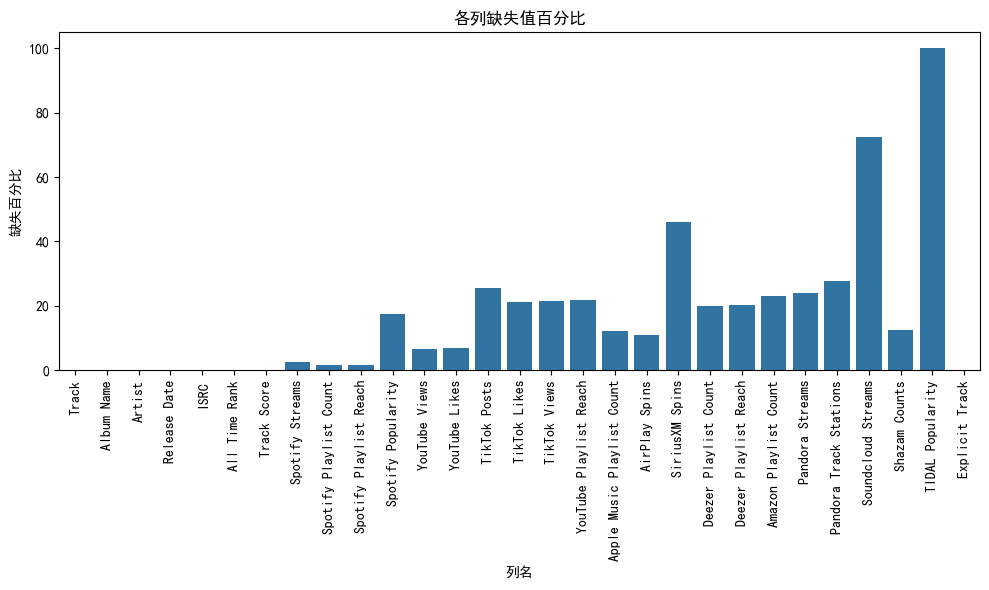

In [ ]:
missing_df = pd.DataFrame({'列名': missing.index, '缺失数量': missing.values, '缺失百分比': missing_percent.values})
plt.figure(figsize=(10,6))
sns.barplot(data=missing_df, x='列名', y='缺失百分比')
plt.xticks(rotation=90)
plt.title('各列缺失值百分比')
plt.tight_layout()
plt.savefig('visual_results/missing_values.png')

#### 2. 播放量分布直方图（对数坐标）

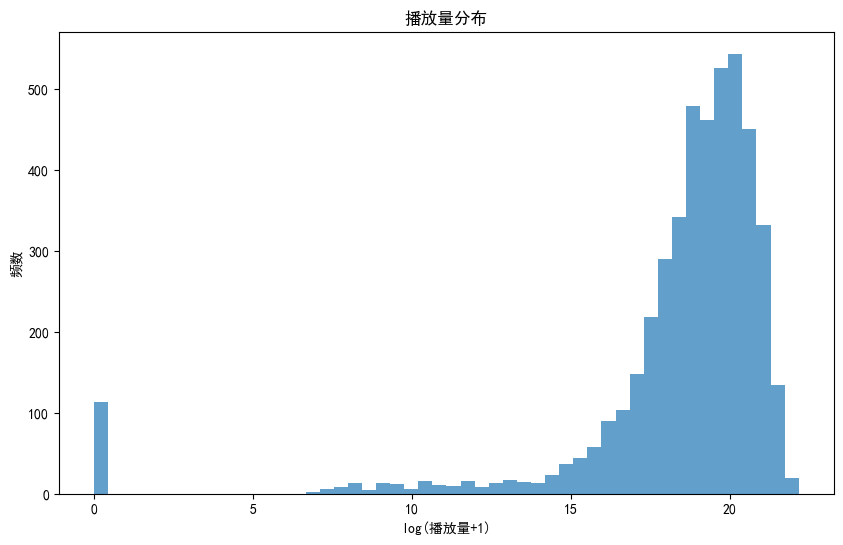

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(np.log1p(df['Spotify Streams']), bins=50, alpha=0.7)
plt.xlabel('log(播放量+1)')
plt.ylabel('频数')
plt.title('播放量分布')
plt.savefig('visual_results/streams_dist.png')

#### 3. 每年发行歌曲平均播放量折线图

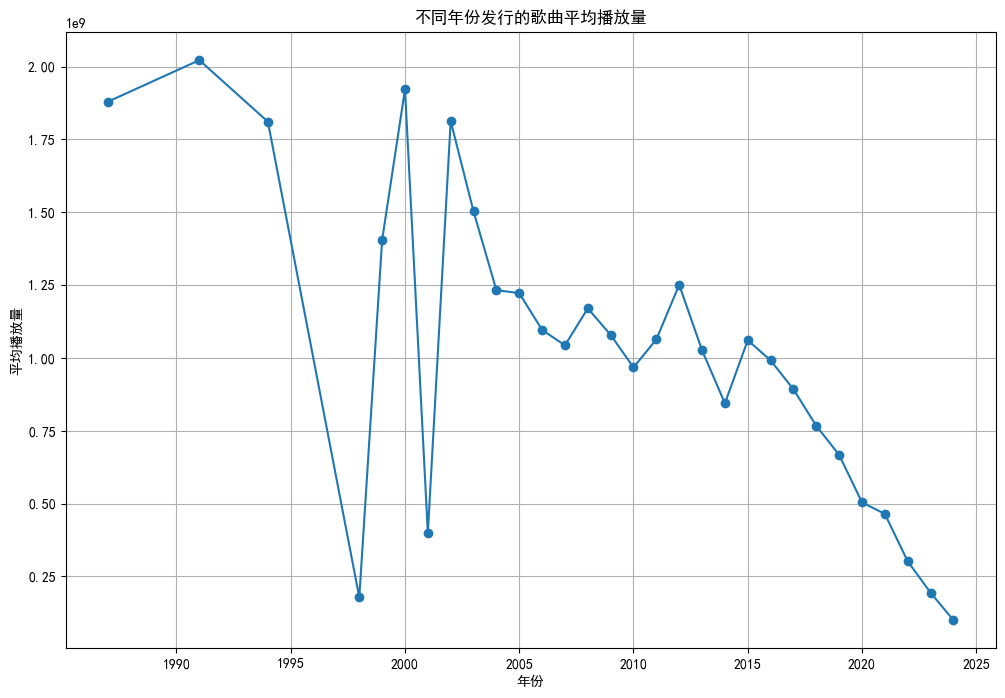

In [10]:
plt.figure(figsize=(12,8))
plt.plot(yearly_avg['Year'], yearly_avg['mean'], marker='o')
plt.xlabel('年份')
plt.ylabel('平均播放量')
plt.title('不同年份发行的歌曲平均播放量')
plt.grid()
plt.savefig('visual_results/yearly_avg.png')

#### 4. 活力分类平均播放量柱状图

In [ ]:
# plt.figure(figsize=(8,5))
# sns.barplot(data=, x='vitality', y='Spotify_Streams')
# plt.title('不同活力歌曲的平均播放量')
# plt.savefig('vitality_avg.png')

#### 5. Top 10 播放量歌曲水平条形图

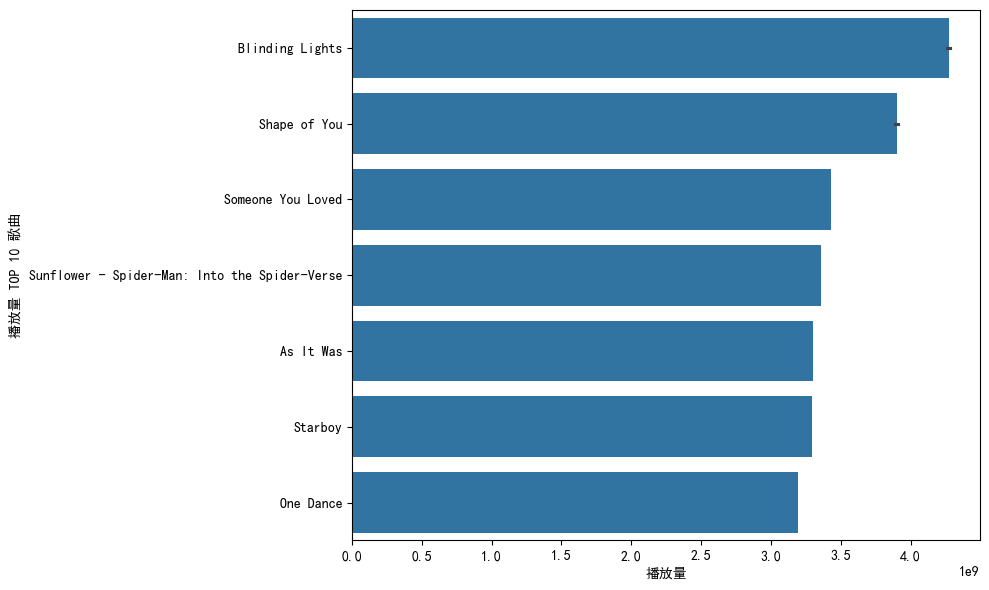

In [12]:
top10 = df.nlargest(10, 'Spotify Streams')
plt.figure(figsize=(10, 6))
sns.barplot(x='Spotify Streams', y='Track', data=top10, orient='h')
plt.xlabel('播放量')
plt.ylabel('播放量 TOP 10 歌曲')
plt.tight_layout()
plt.savefig('visual_results/top10_songs.png')

#### 6.艺术家播放量 Top 10

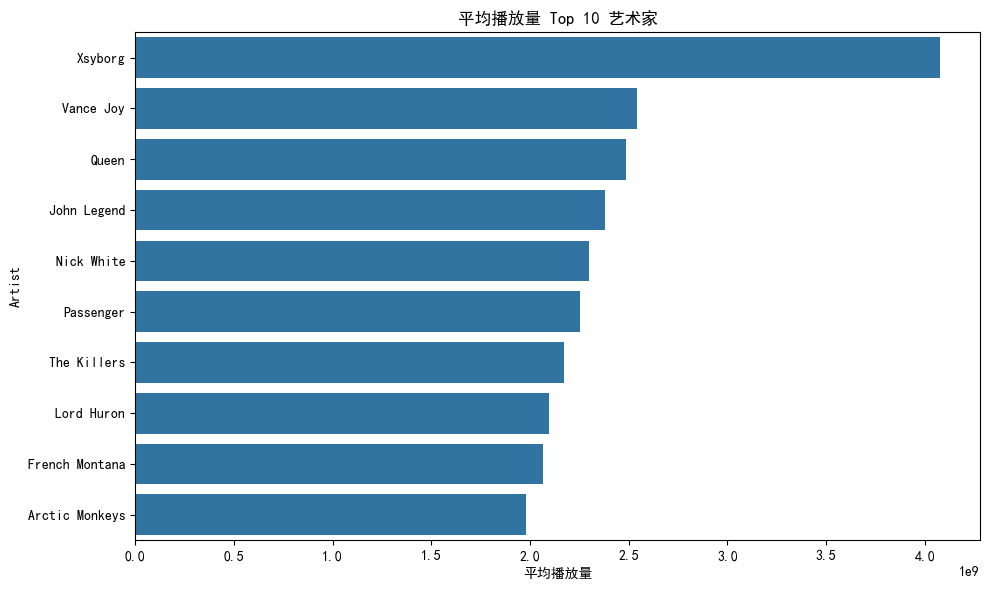

In [14]:
top_artists_avg = df.groupby('Artist')['Spotify Streams'].mean().nlargest(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top_artists_avg, y='Artist', x='Spotify Streams', orient='h')
plt.xlabel('平均播放量')
plt.title('平均播放量 Top 10 艺术家')
plt.tight_layout()
plt.savefig('visual_results/top10_artists.png')